In [1]:
#Data Processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Deep Learning
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

#Image Processing
import os
from pathlib import Path
import joblib
import time

#Machine Learning
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

#Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

#Set Random seeds
np.random.seed(42)
torch.manual_seed(42)

In [2]:
#Configuration

USE_SUBSET = True
SUBSET_SIZE = 2000
BATCH_SIZE = 50

In [3]:
image_dir = Path('fashion-dataset/images')
image_paths = list[Path](image_dir.glob('*.jpg'))

fashion_data = []

for img_path in image_paths:
    fashion_data.append({
        'image_id':img_path.stem,
        'image_path':str(img_path),
        'filename': img_path.name
    })

fashion_df = pd.DataFrame(fashion_data)

fashion_df = fashion_df.sample(SUBSET_SIZE, random_state=42).reset_index(drop=True)


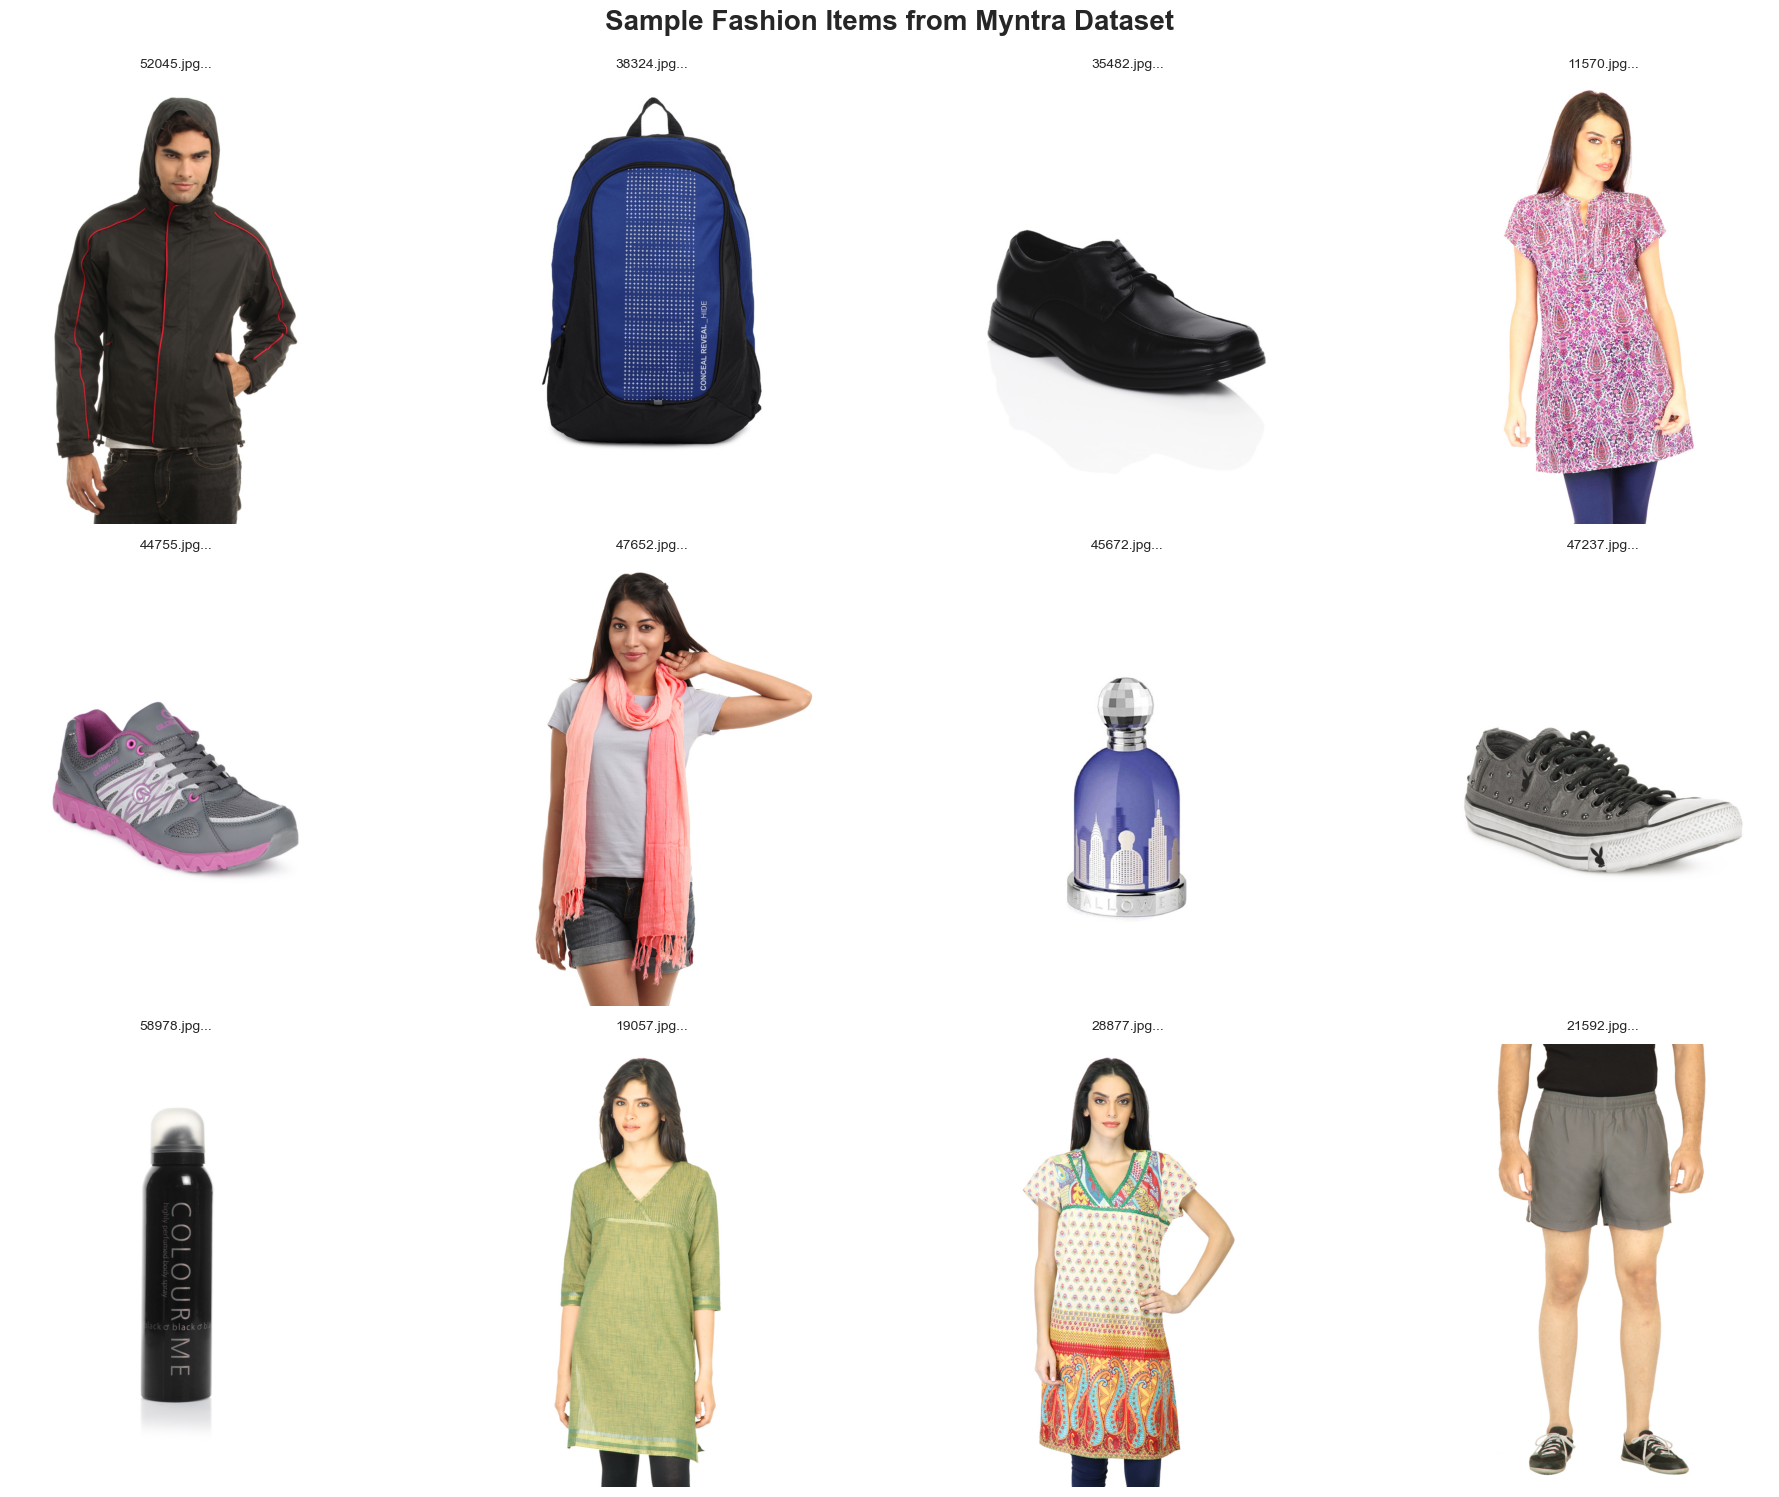

In [4]:
#Display sample images

fig, axes = plt.subplots(3,4, figsize=(20,15))
fig.suptitle('Sample Fashion Items from Myntra Dataset', fontsize=20, fontweight='bold', y=0.995)

sample_items = fashion_df.sample(min(12, len(fashion_df)))

for idx, (ax,(_, item)) in enumerate(zip(axes.flat, sample_items.iterrows())):
    try:
        img = Image.open(item['image_path'])
        ax.imshow(img)
        ax.set_title(f"{item['filename'][:25]}...", fontsize=10, pad =10)
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading{item["filename"][:20]}',
                ha='center', va='center', fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.show()


In [5]:
model = models.resnet18(pretrained=True)

model = nn.Sequential(*list(model.children())[:-1])
model = model.to('cpu')
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]

    )
])

In [ ]:
all_features = []
failed_images = []
start_time = time.time()

for i in range(0, len(fashion_df), BATCH_SIZE):
    batch_df = fashion_df.iloc[i:i+BATCH_SIZE]
    batch_images = []
    batch_indices = []

    for idx, row in batch_df.iterrows():
        try:
            img = Image.open(row['image_path']).convert('RGB')
            img_tensor = transform(img)
            batch_images.append(img_tensor)
            batch_indices.append(idx)
        except Exception as e:
            failed_images.append(row['filename'])
            continue
    if batch_images:
        batch_tensor = torch.stack(batch_images).to('cpu')

        with torch.no_grad():
            features = model(batch_tensor)
            features = features.squeeze().cpu().numpy()

            if len(features.shape) == 1:
                features = features.reshape(1, -1)
            all_features.extend(features)

    if (i + BATCH_SIZE) % 200 == 0 or (i + BATCH_SIZE) >= len(fashion_df):
        elapsed = time.time() - start_time
        progress = min((i + BATCH_SIZE) / len(fashion_df) * 100, 100)
        print(f"Progress: {progress:.1f}% | Processed:{len(all_features):,}/{len(fashion_df):,} | Time : {elapsed:.1f}s")

features_array = np.array(all_features)

if failed_images:
    fashion_df = fashion_df[~fashion_df['filename'].isin(failed_images)].reset_index(drop=True)

elapsed_time = time.time() - start_time

#It extracts features from images using a deep learning model and stores them in an array.

Progress: 10.0% | Processed:200/2,000 | Time : 13.4s
Progress: 20.0% | Processed:400/2,000 | Time : 26.6s
Progress: 30.0% | Processed:600/2,000 | Time : 39.5s
Progress: 40.0% | Processed:800/2,000 | Time : 52.3s
Progress: 50.0% | Processed:1,000/2,000 | Time : 65.9s
Progress: 60.0% | Processed:1,200/2,000 | Time : 81.7s
Progress: 70.0% | Processed:1,400/2,000 | Time : 98.0s
Progress: 80.0% | Processed:1,600/2,000 | Time : 113.1s
Progress: 90.0% | Processed:1,800/2,000 | Time : 126.6s
Progress: 100.0% | Processed:2,000/2,000 | Time : 140.5s


In [7]:
#Build K-Nearest Neighbors model

knn_model = NearestNeighbors(
    n_neighbors=min(20, len(features_array)),
    metric='cosine',
    algorithm='brute'
)

knn_model.fit(features_array)



NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=20)

In [8]:
n_test = min(3, len(fashion_df))

for test_num in range(n_test):
    test_idx = np.random.randint(0, len(fashion_df))
    query_item = fashion_df.iloc[test_idx]

    query_features = features_array[test_idx].reshape(1,-1)
    distances, indices = knn_model.kneighbors(query_features, n_neighbors=7)

    indices = indices[0][1:]
    distances = distances[0][1:]

    recommendations = fashion_df.iloc[indices].copy()
    recommendations['similarity'] = 1 - distances

    print("Top Recommendations")
    for i, (_, rec) in enumerate(recommendations.iterrows(),1):
        print(f" {i}. {rec['filename'][:35]:35} |Similarity: {rec['similarity']:2%}")
    print()

Top Recommendations
 1. 2158.jpg                            |Similarity: 94.364941%
 2. 31581.jpg                           |Similarity: 93.740022%
 3. 2239.jpg                            |Similarity: 93.022931%
 4. 34398.jpg                           |Similarity: 92.805696%
 5. 3727.jpg                            |Similarity: 92.349368%
 6. 31385.jpg                           |Similarity: 91.912377%

Top Recommendations
 1. 26068.jpg                           |Similarity: 93.541127%
 2. 9236.jpg                            |Similarity: 93.287569%
 3. 23953.jpg                           |Similarity: 91.270405%
 4. 29384.jpg                           |Similarity: 90.024483%
 5. 21023.jpg                           |Similarity: 88.688111%
 6. 26066.jpg                           |Similarity: 88.594198%

Top Recommendations
 1. 10877.jpg                           |Similarity: 93.606228%
 2. 17505.jpg                           |Similarity: 93.546945%
 3. 9689.jpg                            |S

In [9]:
n_test = min(3, len(fashion_df))

for test_num in range(n_test):
    test_idx = np.random.randint(0, len(fashion_df))
    query_item = fashion_df.iloc[test_idx]

    query_features = features_array[test_idx].reshape(1,-1)
    distances, indices = knn_model.kneighbors(query_features, n_neighbors=7)

    indices = indices[0][1:]
    distances = distances[0][1:]

    recommendations = fashion_df.iloc[indices].copy()
    recommendations['similarity'] = 1 - distances

    print("Top Recommendations")
    for i, (_, rec) in enumerate(recommendations.iterrows(),1):
        print(f" {i}. {rec['filename'][:35]:35} |Similarity: {rec['similarity']:2%}")
    print()

Top Recommendations
 1. 24648.jpg                           |Similarity: 75.782365%
 2. 14164.jpg                           |Similarity: 72.140098%
 3. 46839.jpg                           |Similarity: 70.367920%
 4. 58050.jpg                           |Similarity: 70.324707%
 5. 48795.jpg                           |Similarity: 70.039880%
 6. 7625.jpg                            |Similarity: 70.026851%

Top Recommendations
 1. 32376.jpg                           |Similarity: 90.421820%
 2. 33882.jpg                           |Similarity: 89.762253%
 3. 25641.jpg                           |Similarity: 89.519894%
 4. 45917.jpg                           |Similarity: 88.079464%
 5. 28577.jpg                           |Similarity: 87.901634%
 6. 11203.jpg                           |Similarity: 87.687355%

Top Recommendations
 1. 43521.jpg                           |Similarity: 93.327349%
 2. 41346.jpg                           |Similarity: 93.082339%
 3. 56849.jpg                           |S